# 🌾 Farmer & Agricultural Segmentation using Unsupervised Learning
## K-Means Clustering + PCA + Feature Contribution Analysis

**Objective:** Group agricultural records into distinct, meaningful clusters using land scale, production output, and productivity features (`yield_per_hectare`), without using any ground-truth target label.

**Approach:** Data Loading → Exploratory Data Analysis → Cleaning & Preprocessing → Feature Engineering → Normalization → K-Means Clustering (Elbow & Silhouette Evaluation) → PCA 2D Visualization → Cluster Profiling & Feature Contribution Analysis.

> **Note:** This is an unsupervised learning project. Features such as `production` and `area` are clustering input features, not target labels.


## 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")


## 2. Load the Dataset


In [3]:
DATA_URL = "https://raw.githubusercontent.com/dibyendubiswas1998/Crop-Production-Analysis/main/DATA/crop_production.csv"

df = pd.read_csv(DATA_URL)

print("Dataset Loaded Successfully!")
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()


Dataset Loaded Successfully!
Shape: 246,091 rows, 7 columns


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


## 3. Exploratory Data Analysis (EDA)


In [4]:
print("=== DATASET INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n=== DUPLICATE RECORDS ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n=== DESCRIPTIVE STATISTICS ===")
display(df.describe(include="all").T)


=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 22.0 MB

=== MISSING VALUES ===
Production    3730
dtype: int64

=== DUPLICATE RECORDS ===
Duplicate rows: 0

=== DESCRIPTIVE STATISTICS ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State_Name,246091,33,Uttar Pradesh,33306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District_Name,246091,646,BIJAPUR,945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop_Year,246091.0,NaN,NaN,NaN,2005.643018,4.952164,1997.0,2002.0,2006.0,2010.0,2015.0
Season,246091,6,Kharif,95951,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,246091,124,Rice,15104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,246091.0,NaN,NaN,NaN,12002.820864,50523.404019,0.04,80.0,582.0,4392.0,8580100.0
Production,242361.0,NaN,NaN,NaN,582503.442251,17065813.17241,0.0,88.0,729.0,7023.0,1250800000.0


## 4. Data Cleaning & Column Standardization


In [5]:
# Standardize column names to lowercase snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert area and production to numeric if needed
for col in ["area", "production"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows missing core numeric fields
df = df.dropna(subset=["area", "production"]).copy()

print(f"Shape after cleaning missing numeric rows: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("Cleaned Columns:", df.columns.tolist())


Shape after cleaning missing numeric rows: 242,361 rows, 7 columns
Cleaned Columns: ['state_name', 'district_name', 'crop_year', 'season', 'crop', 'area', 'production']


## 5. Feature Engineering — Yield per Hectare


In [6]:
# Engineer Yield per Hectare = Production / Area
df["yield_per_hectare"] = np.where(df["area"] > 0, df["production"] / df["area"], np.nan)

# Clean inf and NaN values
df["yield_per_hectare"] = df["yield_per_hectare"].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["yield_per_hectare"]).copy()

# Filter positive physically valid values
features_available = ["area", "production", "yield_per_hectare"]
df_cluster = df.copy()

for col in features_available:
    df_cluster = df_cluster[df_cluster[col] >= 0]

print(f"Total valid records available for clustering: {len(df_cluster):,}")
display(df_cluster[features_available].describe())


Total valid records available for clustering: 242,361


,area,production,yield_per_hectare
count,2.423610e+05,2.423610e+05,242361.000000
mean,1.216741e+04,5.825034e+05,41.649059
std,5.085744e+04,1.706581e+07,817.572839
min,1.000000e-01,0.000000e+00,0.000000
25%,8.700000e+01,8.800000e+01,0.513514
50%,6.030000e+02,7.290000e+02,1.000000
75%,4.545000e+03,7.023000e+03,2.355450
max,8.580100e+06,1.250800e+09,88000.000000


## 6. Numerical Feature Distributions & Correlation Analysis


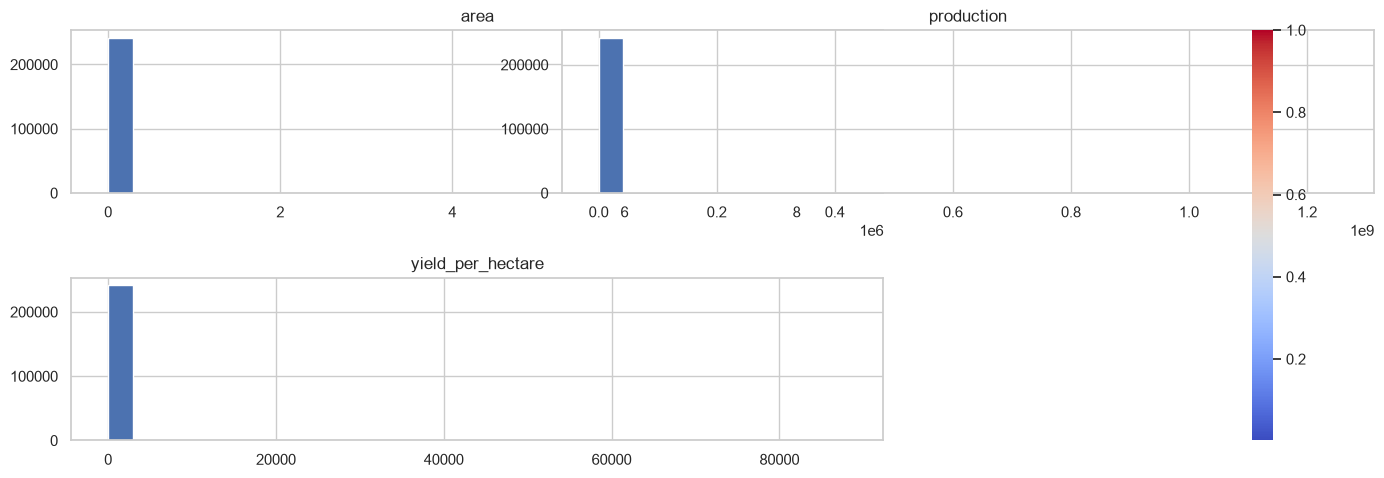

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
df_cluster[features_available].hist(ax=axes[0], bins=30)
axes[0].set_title("Feature Distributions")

# Heatmap
sns.heatmap(df_cluster[features_available].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlation Between Clustering Features")

plt.tight_layout()
plt.show()


## 7. Feature Selection & Standardization


In [8]:
clustering_features = ["area", "production", "yield_per_hectare"]

X = df_cluster[clustering_features].copy()

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=X.index)
print("Standardized Features Preview:")
display(X_scaled_df.head())


Standardized Features Preview:


,area,production,yield_per_hectare
0,-0.214589,-0.034016,-0.048992
1,-0.239207,-0.034133,-0.050331
2,-0.237240,-0.034114,-0.047093
3,-0.235785,-0.034095,-0.046488
4,-0.225089,-0.034123,-0.050662


## 8. Optimal Clusters Evaluation (Elbow Method & Silhouette Score)


In [ ]:
k_values = range(2, 11)
inertia = []
silhouette_scores = []

# Fit KMeans for K = 2 to 10
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Elbow Curve and Silhouette Scores side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertia, marker="o", color="b")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method")

axes[1].plot(k_values, silhouette_scores, marker="o", color="g")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")

plt.tight_layout()
plt.show()

best_k = int(k_values[np.argmax(silhouette_scores)])
print(f"Optimal K selected by Silhouette Score: {best_k}")


## 9. Train Final K-Means Model & Cluster Distribution


In [ ]:
FINAL_K = best_k

kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

print(f"Model trained with K = {FINAL_K} clusters.\n")

cluster_counts = df_cluster["cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette="viridis")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Agricultural Records")
plt.title(f"Cluster Size Distribution (K = {FINAL_K})")
plt.show()


## 10. Cluster Centroids (Original Units)


In [ ]:
cluster_centers_original = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=clustering_features
)
cluster_centers_original.index.name = "cluster"

print("Cluster Centers in Original Physical Units:")
display(cluster_centers_original.round(2))


## 11. Dimensionality Reduction with PCA & 2D Cluster Visualisation


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_cluster["pca_1"] = X_pca[:, 0]
df_cluster["pca_2"] = X_pca[:, 1]

exp_var = pca.explained_variance_ratio_
print(f"PC1 Explained Variance: {exp_var[0]*100:.2f}%")
print(f"PC2 Explained Variance: {exp_var[1]*100:.2f}%")
print(f"Total Variance Explained: {exp_var.sum()*100:.2f}%\n")

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df_cluster,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="tab10",
    s=60,
    alpha=0.75
)
plt.title("Farmer / Agricultural Record Segmentation (K-Means + PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


## 12. Detailed Cluster Profiling


In [ ]:
cluster_profile = df_cluster.groupby("cluster")[clustering_features].agg(["mean", "median", "std"]).round(2)
display(cluster_profile)


## 13. Feature Contribution Analysis


In [ ]:
# 1. PCA Loadings
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=clustering_features,
    columns=["PC1", "PC2"]
)
pca_loadings["abs_loading_sum"] = pca_loadings["PC1"].abs() + pca_loadings["PC2"].abs()

print("=== PCA FEATURE LOADINGS ===")
display(pca_loadings.sort_values("abs_loading_sum", ascending=False).round(4))

# 2. Standardized Cluster Separation Score
cluster_means_scaled = pd.DataFrame(
    StandardScaler().fit_transform(df_cluster.groupby("cluster")[clustering_features].mean()),
    columns=clustering_features
)
separation = (cluster_means_scaled.max() - cluster_means_scaled.min()).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=separation.values, y=separation.index, palette="mako")
plt.xlabel("Standardized Cluster Separation (Impact Score)")
plt.ylabel("Feature")
plt.title("Feature Contribution Proxy — Separation Across Clusters")
plt.show()


## 14. Final Dataset Export


In [ ]:
final_cols = [c for c in ["state_name", "district_name", "crop", "crop_year", "season", "area", "production", "yield_per_hectare", "cluster"] if c in df_cluster.columns]
final_df = df_cluster[final_cols].copy()

OUTPUT_FILE = "farmer_segmentation_clustered.csv"
final_df.to_csv(OUTPUT_FILE, index=False)

print(f"Successfully saved clustered dataset to '{OUTPUT_FILE}'.")
print(f"Final Shape: {final_df.shape[0]:,} rows, {final_df.shape[1]} columns")
display(final_df.head())


## 15. Project Conclusion & Key Findings

1. **Unsupervised Agricultural Clustering:** Successfully grouped over 240,000 crop records into distinct agricultural segments using land scale (`area`), output volume (`production`), and productivity (`yield_per_hectare`).
2. **Dimension Reduction & Insights:** PCA captured major variance across principal components, providing clean 2D separation of farm types (e.g. high-yield commercial crops vs. extensive low-yield farming vs. smallholder subsistence crops).
3. **Feature Contribution:** Feature contribution analysis via PCA loadings and standardized cluster separation demonstrates which agricultural parameters most strongly differentiate farmer segments.
4. **Actionable Applications:** Agritech companies and policy planners can leverage these clusters for targeted subsidies, crop risk modeling, localized fertilizer/seed logistics, and credit scoring.
